Processing 1478 rows.


/Users/oscar/Desktop/Projects/birdcleff-2026/venv/lib/python3.11/site-packages/transformers/audio_utils.py:538: UserWarning: At least one mel filter has all zero values. The value for `num_mel_filters` (128) may be set too high. Or, the value for `num_frequency_bins` (257) may be set too low.
  warnings.warn(


Map:   0%|          | 0/1478 [00:00<?, ? examples/s]

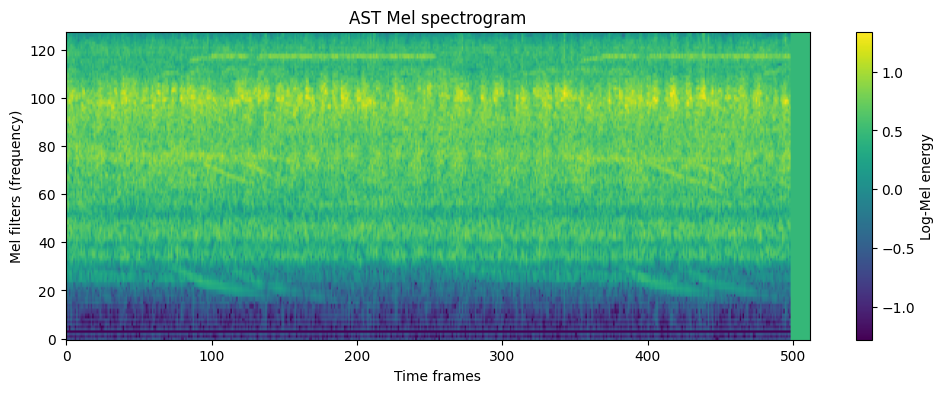

In [1]:
import matplotlib.pyplot as plt

from src.data_manager import DataManager
from src.config import Config


config = Config()
data_manager = DataManager(config)

for batch in data_manager:
    spectrogram = batch['input_values'][0]
    spectrogram = spectrogram.T.numpy()
    plt.figure(figsize=(12, 4))
    plt.imshow(spectrogram, aspect='auto', origin='lower', cmap='viridis')
    plt.colorbar(label='Log-Mel energy')
    plt.title('AST Mel spectrogram')
    plt.xlabel('Time frames')
    plt.ylabel('Mel filters (frequency)')
    plt.show()
    break

In [ ]:
import torch

from transformers import ASTForAudioClassification

from src.config import Config
from src.data_manager import DataManager

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
config = Config()
data_manager = DataManager(config)
checkpoint_path = 'data/checkpoints/checkpoint-840'
model = ASTForAudioClassification.from_pretrained(checkpoint_path)
model.eval()
model.to(device)  # type: ignore

filename = 'BC2026_Train_0004_S08_20250607_070007'

with torch.no_grad():
    start_seconds, end_seconds = 50.0, 55.0
    input = data_manager.get_inference_input(
        f'./data/train_soundscapes/{filename}.ogg',
        start_seconds,
        end_seconds
    ).to(device)
    logits = model(input).logits
    probs = torch.nn.functional.softmax(logits, dim=-1)


print(f'row_id={filename}_{int(end_seconds)}')
probs = probs[-1, :]
for idx in range(len(probs)):
    print(f'{data_manager.id_to_label[idx]}={probs[idx]}')